<a href="https://colab.research.google.com/github/priyalimbu246/Valson-course/blob/main/Copy_of_Lecture_13_Regression_with_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 13 - Regression

Here we are going to regression modeling on the Bradley Melting Point Dataset, which is curated chemical dataset with melting points of around 3,000 chemical compounds, see [here](https://www.kaggle.com/datasets/aliffaagnur/melting-point-chemical-dataset/data).

We will use the [LightGBM](https://en.wikipedia.org/wiki/LightGBM) method is seperate from scikit-learn but uses the same API.

This is heavily inspired by this tutorial:
- [Building a Simple Regression Model](https://colab.research.google.com/github/PatWalters/practical_cheminformatics_tutorials/blob/main/ml_models/regression_model.ipynb)


Install RDKit and [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit lightgbm mols2grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.7 MB/s eta 0:00:00


Import all basic pacakges

In [ ]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# For progress bar
from tqdm.auto import tqdm

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# LightGBM
from lightgbm import LGBMRegressor, plot_importance

# mols2grid
import mols2grid

# To visluzise results
from yellowbrick.regressor import prediction_error, ResidualsPlot

Download dataset

In [ ]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="BradleyDoublePlusGoodMeltingPointDataset.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

BradleyDoublePlusGoodMeltingPointDataset.csv
sample_data


This is to add progress bars panda task

In [ ]:
tqdm.pandas()

Read dataset

In [ ]:
data_mp = pd.read_csv("BradleyDoublePlusGoodMeltingPointDataset.csv")



In [ ]:
data_mp

,key,name,smiles,mpC,csid,link,source,count,min,max,range
0,27956,cyclobutylmethane,C1(CCC1)C,-161.51,11232,http://pubs.acs.org/doi/abs/10.1021/ja01142a048,Lemaire HP; Livingston RL Journal of the Ameri...,2,-161.51,-161.5,0.01
1,16005,Nitrogen oxide,[O-][N+]#N,-90.80,923,http://msds.chem.ox.ac.uk/,academic website,2,-90.81,-90.8,0.01
2,16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.80,16647,http://msds.chem.ox.ac.uk/,academic website,2,-135.82,-135.8,0.02
3,17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.80,3002,http://dx.doi.org/10.1021/ci700307p,Hughes LD; Palmer DS; Nigsch F and Mitchell JB...,2,94.75,94.8,0.05
4,15628,Bromine,BrBr,-7.20,22817,http://msds.chem.ox.ac.uk/,academic website,2,-7.25,-7.2,0.05
...,...,...,...,...,...,...,...,...,...,...,...
3036,27698,4-Nitrobenzoic acid,C1=CC(=CC=C1C(=O)O)[N+](=O)[O-],240.00,5882,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,6,237.00,242.0,5.00
3037,28584,Thalidomide,C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O,275.00,5233,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,270.00,275.0,5.00
3038,28068,Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,176.00,5554,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,7,173.00,178.0,5.00
3039,27580,"2,4,6-Trichlorophenol",C1=C(C=C(C(=C1Cl)O)Cl)Cl,65.00,21106172,http://dx.doi.org/10.1016/j.chemosphere.2013.1...,Abraham M.H. and Acree Jr. W.E. The solubility...,9,65.00,70.0,5.00


In [ ]:
# Simplify by removing columns from the data frame
data_mp = data_mp.drop(columns=['csid','link','source','count','min','max','range'])

Let's visualize the molecules using mols2grid.

In [ ]:
def mp_str(x):
    return f'{x:.2f} C'

mols2grid.display(data_mp,
                  smiles_col='smiles',
                  subset=['img','name','mpC'],
                  transform={"mpC": mp_str})

## SMILES ARbitrary Target Specification (SMARTS)

SMARTS is a very useful method to look for substructures in molecules using RDKit and it can be used in various ways in RDKit, for example to delete parts. We can use it to search in the mols2grid above.

See these excellent tutorials for further information about SMARTS:
- [An introduction to the SMILES ARbitrary Target Specification (SMARTS)](https://colab.research.google.com/github/PatWalters/practical_cheminformatics_tutorials/blob/main/fundamentals/SMARTS_tutorial.ipynb)
- [Recursive SMARTS](https://colab.research.google.com/github/PatWalters/practical_cheminformatics_tutorials/blob/main/fundamentals/recursive_smarts.ipynb)
- (SMARTS Tutorial)[https://www.daylight.com/dayhtml_tutorials/languages/smarts/]

For example, we can use the following:
- Benzene rings: `c1ccccc1[#6]`
- Atoms with charges -1 or +1: `[-1]` or `[+1]`
- Nitrogen or oxygen attached to an aliphatic carbon: `C[#7,#8]`

Try to search for certain SMARTS string in the mols2grid object above.

## Calculate RDKit Features

Here we use a quick way to calculate a large set of properties. Will be explained in class.

In [ ]:
property_names = list(rdMolDescriptors.Properties.GetAvailableProperties())


In [ ]:
property_names

['exactmw',
 'amw',
 'lipinskiHBA',
 'lipinskiHBD',
 'NumRotatableBonds',
 'NumHBD',
 'NumHBA',
 'NumHeavyAtoms',
 'NumAtoms',
 'NumHeteroatoms',
 'NumAmideBonds',
 'FractionCSP3',
 'NumRings',
 'NumAromaticRings',
 'NumAliphaticRings',
 'NumSaturatedRings',
 'NumHeterocycles',
 'NumAromaticHeterocycles',
 'NumSaturatedHeterocycles',
 'NumAliphaticHeterocycles',
 'NumSpiroAtoms',
 'NumBridgeheadAtoms',
 'NumAtomStereoCenters',
 'NumUnspecifiedAtomStereoCenters',
 'labuteASA',
 'tpsa',
 'CrippenClogP',
 'CrippenMR',
 'chi0v',
 'chi1v',
 'chi2v',
 'chi3v',
 'chi4v',
 'chi0n',
 'chi1n',
 'chi2n',
 'chi3n',
 'chi4n',
 'hallKierAlpha',
 'kappa1',
 'kappa2',
 'kappa3',
 'Phi']

In [ ]:
property_getter = rdMolDescriptors.Properties(property_names)

In [ ]:
property_getter

In [ ]:
mol=Chem.MolFromSmiles("c1ccccc1CC")
print(np.array(property_getter.ComputeProperties(mol)))



[106.07825032 106.168        0.           0.           1.
   0.           0.           8.          18.           0.
   0.           0.25         1.           1.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.          50.16128735
   0.           2.249       35.82         5.09385813   2.97134377
   1.25107295   1.25107295   0.71371283   5.09385813   2.97134377
   1.25107295   1.25107295   0.71371283  -0.78         5.35850416
   2.50834781   1.0935372    1.68012402]


In [ ]:
property_names_2=['tpsa','NumRotatableBonds']
property_getter_2 = rdMolDescriptors.Properties(property_names_2)
mol=Chem.MolFromSmiles("c1ccccc1CC")
print(np.array(property_getter_2.ComputeProperties(mol)))

[0. 1.]


In [ ]:
def smi2props(smi):
    mol = Chem.MolFromSmiles(smi)
    props = None
    if mol:
        Chem.DeleteSubstructs(mol, Chem.MolFromSmarts("[#1X0]"))
        props = np.array(property_getter.ComputeProperties(mol))
    return props

In [ ]:
data_mp['props']=[smi2props(s) for s in data_mp['smiles']]

In [ ]:
# These two ways are equilivant

data_mp['props'] = data_mp.smiles.progress_apply(smi2props)

# data_mp['props'] = data_mp['smiles'].progress_apply(smi2props)

  0%|          | 0/3025 [00:00<?, ?it/s]

In [ ]:
# data_mp = data_mp.dropna(subset=['props']) # The 'props' column was already processed and dropped.

In [ ]:
data_mp

,key,name,smiles,mpC,exactmw,amw,lipinskiHBA,lipinskiHBD,NumRotatableBonds,NumHBD,...,chi0n,chi1n,chi2n,chi3n,chi4n,hallKierAlpha,kappa1,kappa2,kappa3,Phi
0,27956,cyclobutylmethane,C1(CCC1)C,-161.51,70.078250,70.135,0.0,0.0,0.0,0.0,...,3.698671,2.393847,1.393847,1.393847,0.612372,0.00,3.200000,1.000000,0.444444,0.640000
1,16005,Nitrogen oxide,[O-][N+]#N,-90.80,44.001063,44.013,3.0,0.0,0.0,0.0,...,1.302675,0.382574,0.000000,0.000000,0.000000,-0.78,2.220000,1.220000,1.220000,0.902800
2,16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.80,101.958707,102.061,2.0,0.0,0.0,0.0,...,1.980674,0.641940,0.000000,0.000000,0.000000,-0.19,4.810000,0.891221,345.760139,0.857354
3,17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.80,339.231063,339.483,4.0,2.0,8.0,1.0,...,15.645092,8.919544,4.860955,4.860955,3.559345,-2.20,19.129073,8.255621,4.074327,6.316895
4,15628,Bromine,BrBr,-7.20,157.836674,159.808,0.0,0.0,0.0,0.0,...,0.755929,0.142857,0.000000,0.000000,0.000000,0.96,2.960000,1.960000,0.001667,2.900800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3036,27698,4-Nitrobenzoic acid,C1=CC(=CC=C1C(=O)O)[N+](=O)[O-],240.00,167.021858,167.120,5.0,1.0,2.0,1.0,...,5.928573,3.087853,1.325074,1.325074,0.725723,-1.91,8.189108,2.996670,1.570829,2.045005
3037,28584,Thalidomide,C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O,275.00,258.064057,258.233,6.0,1.0,1.0,1.0,...,9.881172,5.899736,3.347260,3.347260,2.419425,-2.50,11.582542,4.012158,1.640224,2.445841
3038,28068,Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,176.00,272.177630,272.388,2.0,2.0,0.0,2.0,...,12.178520,8.092632,6.660104,6.660104,5.541204,-1.02,12.700482,4.236678,1.604792,2.690393
3039,27580,"2,4,6-Trichlorophenol",C1=C(C=C(C(=C1Cl)O)Cl)Cl,65.00,195.924948,197.448,1.0,1.0,0.0,1.0,...,4.735808,2.445254,0.981666,0.981666,0.534585,-0.11,7.991112,2.868476,1.483432,2.292232


In [ ]:
# data_mp[property_names] = data_mp['props'].tolist() # This line caused an error because the 'props' column was already dropped.

In [ ]:
# data_mp.drop("props",axis=1,inplace=True) # This column was already dropped in a previous execution

## Train using LightGBM

In [ ]:
train, test = train_test_split(data_mp,test_size=0.20)

In [ ]:
train_X = train[property_names]
train_y = train.mpC
test_X = test[property_names]
test_y = test.mpC

In [ ]:
lgbm = LGBMRegressor()
lgbm.fit(train_X, train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5677
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 42
[LightGBM] [Info] Start training from score 62.811182


LGBMRegressor()

In [ ]:
pred = lgbm.predict(test_X)

[Text(0, 0.5, 'Predicted mpC')]

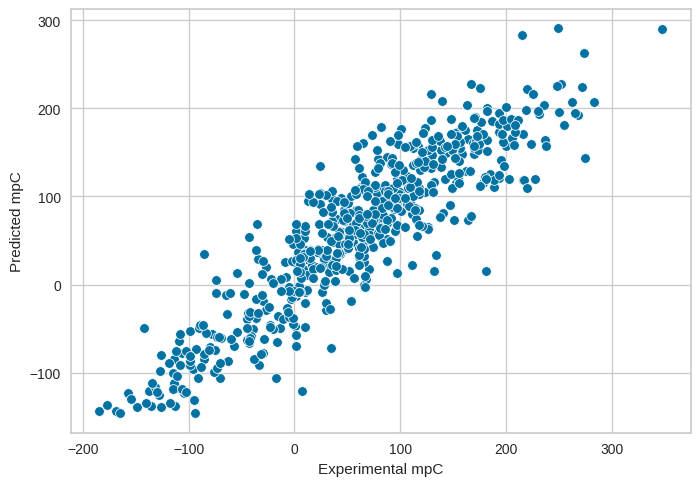

In [ ]:
ax = sns.scatterplot(x=test_y,y=pred)
ax.set(xlabel="Experimental mpC")
ax.set(ylabel="Predicted mpC")

[Text(0, 0.5, 'Predicted mpC')]

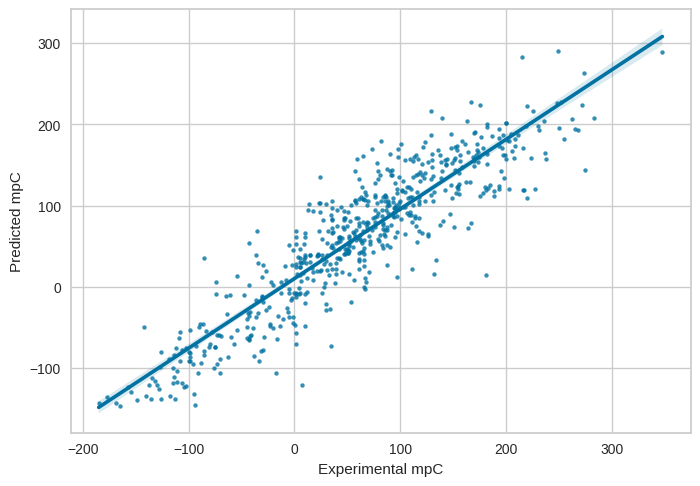

In [ ]:
ax = sns.regplot(x=test_y,y=pred,scatter_kws={'s':10})
ax.set(xlabel="Experimental mpC")
ax.set(ylabel="Predicted mpC")

In [ ]:
r2_score(test_y,pred)

0.8165827966269034

In [ ]:
mean_squared_error(test_y,pred)

1584.3725768084594

[Yellowbrick](https://www.scikit-yb.org/en/latest/) is python package that extends scikit-learn in various ways, including visualization, that we use here.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


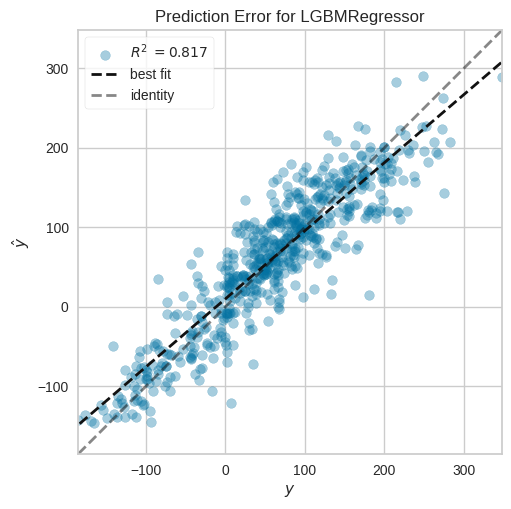

In [ ]:


visualizer = prediction_error(lgbm, train_X, train_y, test_X, test_y,alpha=0.35)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


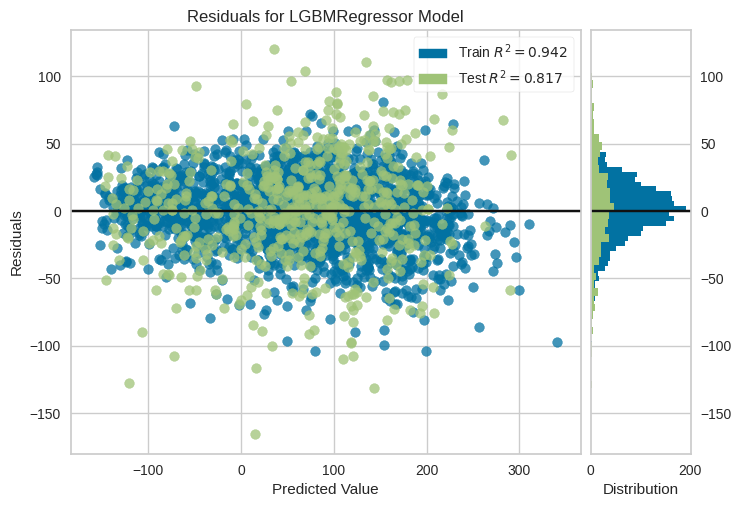

In [ ]:
visualizer = ResidualsPlot(lgbm)
visualizer.fit(train_X, train_y)
visualizer.score(test_X, test_y)
visualizer.show();

### Feature Importance

Let's do feature importance

In [ ]:
features_importance = lgbm.feature_importances_

##log10 Transform

In [ ]:
data_mp['mpC_log10'] = np.log10(data_mp['mpC'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
train, test = train_test_split(data_mp,test_size=0.20)
train_X = train[property_names]
train_y = train.mpC_log10
test_X = test[property_names]
test_y = test.mpC_log10

In [ ]:
lgbm = LGBMRegressor()
lgbm.fit(train_X, train_y)
test_pred = lgbm.predict(test_X)
test_pred_exp = 10**test_pred

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5679
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 42
[LightGBM] [Info] Start training from score -82644625456906553673447776796540928.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/tmp/ipykernel_1245/3543916934.py:4: RuntimeWarning: overflow encountered in power
  test_pred_exp = 10**test_pred


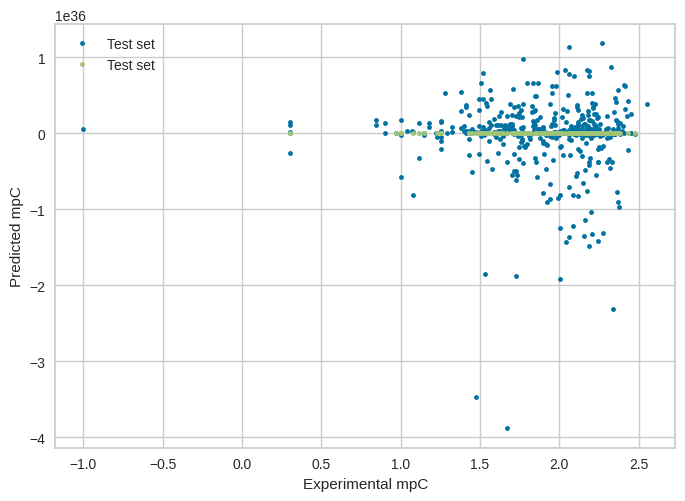

In [ ]:
plt.plot(test_y,test_pred,'.',label='Test set')
plt.plot(test_y,test_pred_exp,'.',label='Test set')
plt.xlabel('Experimental mpC')
plt.ylabel('Predicted mpC')
plt.legend()

##Scramble

In [ ]:
train, test = train_test_split(data_mp,test_size=0.20)
train_X = train[property_names]
train_y = train.mpC_log10
test_X = test[property_names]
test_y = test.mpC_log10

In [ ]:
lgbm = LGBMRegressor()
lgbm.fit(train_X, train_y)
test_pred = lgbm.predict(test_X)
test_pred_exp = 10**test_pred

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5672
[LightGBM] [Info] Number of data points in the train set: 2420, number of used features: 42
[LightGBM] [Info] Start training from score -82644625456906553673447776796540928.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/tmp/ipykernel_1245/3543916934.py:4: RuntimeWarning: overflow encountered in power
  test_pred_exp = 10**test_pred


## Cross Validation

In [ ]:
r2_list = []
rmse_list = [] # Initialize rmse_list
NumberOfRandomShuffles=100
for i in tqdm(range(0,NumberOfRandomShuffles)):
    # setup training and test sets
    train, test = train_test_split(data_mp)
    train_X = train[property_names]
    train_y = train.mpC
    test_X = test[property_names]
    test_y = test.mpC
    # create the regressor
    lgbm = LGBMRegressor()
    # train the model
    lgbm.fit(train_X,train_y)
    pred = lgbm.predict(test_X)
    r2 = r2_score(test_y,pred)
    rmse = np.sqrt(mean_squared_error(test_y,pred)) # Calculate RMSE by taking sqrt of MSE
    print(f"R^2: {r2:.3f}, RMSE: {rmse:.3f}") # Print both metrics for feedback
    r2_list.append(r2)
    rmse_list.append(rmse) # Append RMSE

  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5661
[LightGBM] [Info] Number of data points in the train set: 2268, number of used features: 42
[LightGBM] [Info] Start training from score 62.085384
R^2: 0.814, RMSE: 40.583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5662
[LightGBM] [Info] Number of data points in the train set: 2268, number of used features: 42
[LightGBM] [Info] Start training from score 61.896499
R^2: 0.810, RMSE: 41.084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set

In [ ]:
r2_mean=np.mean(r2_list)
r2_stddeve=np.std(r2_list)
rmse_mean=np.mean(rmse_list)
rmse_stddeve=np.std(rmse_list)
print(f"R^2: {r2_mean:.3f} +- {r2_stddeve:.3f}")
print(f"RMSE: {rmse_mean:.3f} +- {rmse_stddeve:.3f}")

R^2: 0.805 +- 0.011
RMSE: 42.204 +- 1.224


[Text(0.5, 0, 'R$^2$')]

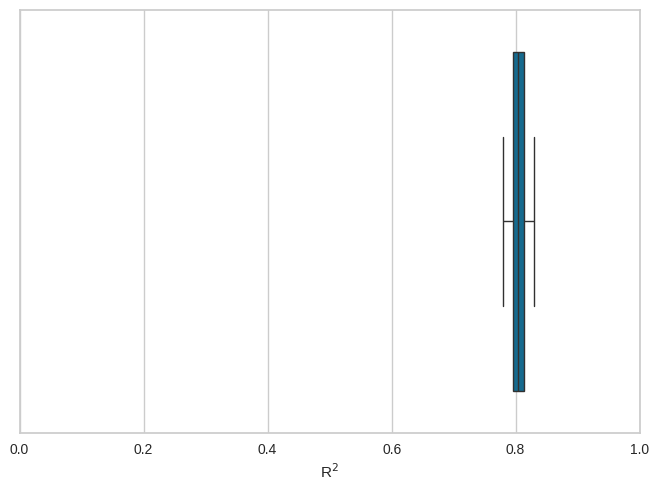

In [ ]:
ax = sns.boxplot(x=r2_list)
ax.set(xlim=(0,1))
ax.set(xlabel="R$^2$")

### Random Forrest

Repeat the analysis using Random Forrest Regreesion

##Home Work